## SETTING UP DOWNLOAD URL

### URL CREATION

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

# --------------------------------------------------
# 1. Setup
# --------------------------------------------------

BASE_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
PERIOD = "202510"
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)

zip_path = output_dir / file_name

# ---------------------------------------------c-----
# 2. Download one ZIP file
# --------------------------------------------------

url = f"{BASE_URL}/{file_name}"

print("downloading form:  ", url)
print("saving into:  ", zip_path)

### Downlaoding ZIP FILE

In [ ]:
urlretrieve(url,zip_path)

In [ ]:
with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted files into: {output_dir}")

In [ ]:
zip_path.unlink()
print("ZIP file removed.")

### Downlaod All

In [ ]:
YEAR = [2025]
MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(12)]

In [ ]:
def download_periods(year:list,start_m:int, stop_m:int)->list:
    """
    
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    print(periods)
    return periods



In [ ]:
download_periods(['2025'],10,12)

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

BASE_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike"
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)

periods = download_periods(['2025'],10,12)

print(periods)
for  period in periods:
    file_name = f"JC-{period}-citibike-tripdata.csv.zip"


    zip_path = output_dir / file_name
    url = f"{BASE_URL}/{file_name}"

    print("downloading form:  ", url)
    
    urlretrieve(url,zip_path)
    
    print("saving into:  ", zip_path)


    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)


    print(f"Extracted files into: {output_dir}")

    zip_path.unlink()
    print("ZIP file removed.")



### Checking One 

In [14]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob('../data/citibike/*.csv')



dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(file_name)
    print(df.columns, 2*"||",len(df.columns))

    cols.append(list(df.columns))
    dfs.append(df)




../data/citibike/JC-202511-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202507-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202505-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
../data/citibike/JC-202503-citibike-tripdata.csv
Index(['ride_id', 'rideable_type', 'sta

In [24]:
citibike_df = pd.concat(dfs)
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member


### Forcing Dates

In [26]:
citibike_df['started_at'] = pd.to_datetime(citibike_df['started_at'],errors="coerce")
citibike_df['ended_at'] = pd.to_datetime(citibike_df['ended_at'],errors="coerce")

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member


### Handling the missing values

In [27]:
missing_values = (
    citibike_df
    .isna()
    .sum()
    .reset_index()
)

missing_values.columns = ["column", "missing_count"]

missing_values["missing_share"] = (
    missing_values["missing_count"] / len(citibike_df)
)

missing_values.sort_values("missing_count", ascending=False)

,column,missing_count,missing_share
7,end_station_id,8794,0.004385
10,end_lat,6888,0.003435
11,end_lng,6888,0.003435
6,end_station_name,6470,0.003226
4,start_station_name,6,0.000003
5,start_station_id,6,0.000003
8,start_lat,4,0.000002
9,start_lng,4,0.000002
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


In [31]:
citibike_df = citibike_df.dropna(
    subset=[
        "ride_id",
        "started_at",
        "ended_at",
        "start_lat",
        "start_lng",
        "end_lat",
        "end_lng"
    ]
)



### Ride Duration

Removing extremes

In [30]:
citibike_df["ride_duration_minutes"] = (
    citibike_df["ended_at"] - citibike_df["started_at"]
).dt.total_seconds() / 60

In [ ]:
citibike_df = citibike_df[
    (citibike_df["ride_duration_minutes"] > 1) &
    (citibike_df["ride_duration_minutes"] <= 24 * 60)
].copy()

### Time Based Variables

In [32]:
citibike_df["date"] = citibike_df["started_at"].dt.date
citibike_df["month"] = citibike_df["started_at"].dt.to_period("M").astype(str)
citibike_df["month_name"] = citibike_df["started_at"].dt.month_name()
citibike_df["day_of_week"] = citibike_df["started_at"].dt.day_name()
citibike_df["hour"] = citibike_df["started_at"].dt.hour

In [33]:
def assign_season(month_number):
    if month_number in [12, 1, 2]:
        return "Winter"
    elif month_number in [3, 4, 5]:
        return "Spring"
    elif month_number in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


citibike_df["season"] = (
    citibike_df["started_at"]
    .dt.month
    .apply(assign_season)
)

In [34]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


In [25]:
monthly_rides = (
    citibike_df
    .groupby("month", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

monthly_rides

KeyError: 'month'

## Weather Data | API

In [10]:
import pandas as pd
import requests

lat = 40.7178
lng = -74.0431

start_date = "2025-01-01"
end_date = "2025-12-31"

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lng,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()



weather_daily = pd.DataFrame(data["daily"])
weather_daily["date"] = pd.to_datetime(weather_daily["time"])
weather_daily = weather_daily.drop(columns="time")

weather_daily.tail()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,date
360,-1.0,-7.3,-3.6,5.3,0.4,3.43,16.3,2025-12-27
361,1.0,-11.6,-5.8,0.9,0.9,0.00,9.4,2025-12-28
362,7.3,-1.4,3.5,3.9,3.9,0.00,23.8,2025-12-29
363,-0.2,-3.0,-1.3,0.0,0.0,0.00,25.5,2025-12-30
364,-0.2,-3.7,-2.2,0.0,0.0,0.00,16.5,2025-12-31


In [3]:
weather_daily = weather_daily[['date','temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max'
       ]]

weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-01-01,7.7,0.2,3.5,0.0,0.0,0.0,14.3
1,2024-01-02,5.7,-4.6,0.0,0.0,0.0,0.0,13.7
2,2024-01-03,7.7,-2.3,1.5,0.0,0.0,0.0,14.4
3,2024-01-04,6.8,-2.1,2.0,0.0,0.0,0.0,26.9
4,2024-01-05,3.1,-5.3,-1.8,0.0,0.0,0.0,20.5


### Whether Analytics

In [12]:
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   temperature_2m_max   365 non-null    float64       
 1   temperature_2m_min   365 non-null    float64       
 2   temperature_2m_mean  365 non-null    float64       
 3   precipitation_sum    365 non-null    float64       
 4   rain_sum             365 non-null    float64       
 5   snowfall_sum         365 non-null    float64       
 6   wind_speed_10m_max   365 non-null    float64       
 7   date                 365 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


### Merging

In [37]:
daily_rides = (
    citibike_df
    .groupby("date", as_index=False)
    .agg(
        number_of_rides=("ride_id", "count")
    )
)
daily_rides["date"] = pd.to_datetime(daily_rides["date"])
daily_rides.head()


,date,number_of_rides
0,2024-12-31,4
1,2025-01-01,2358
2,2025-01-02,3420
3,2025-01-03,3542
4,2025-01-04,2674


In [38]:
bike_weather_daily = daily_rides.merge(
    weather_daily,
    on="date",
    how="left"
)
bike_weather_daily

,date,number_of_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,2358,10.9,3.9,7.4,4.5,4.5,0.00,23.2
2,2025-01-02,3420,5.4,0.3,2.6,0.0,0.0,0.00,25.1
3,2025-01-03,3542,3.2,-1.9,0.4,0.0,0.0,0.00,17.1
4,2025-01-04,2674,-0.1,-2.7,-1.4,0.0,0.0,0.00,26.1
...,...,...,...,...,...,...,...,...,...
361,2025-12-27,574,-1.0,-7.3,-3.6,5.3,0.4,3.43,16.3
362,2025-12-28,976,1.0,-11.6,-5.8,0.9,0.9,0.00,9.4
363,2025-12-29,1904,7.3,-1.4,3.5,3.9,3.9,0.00,23.8
364,2025-12-30,2284,-0.2,-3.0,-1.3,0.0,0.0,0.00,25.5


## DEMO `DF`

In [48]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path


url = '../data/citibike/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


<Axes: >

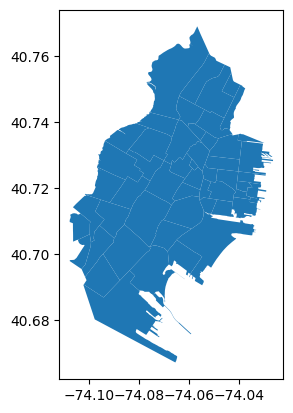

In [49]:
jersey_city.plot()

In [47]:
import json
from pathlib import Path

input_path = Path("../data/citibike/jersey-city-neighborhoods.json")
output_path = Path("../data/citibike/jersey-city-neighborhoods.geojson")

# Read original JSON
with open(input_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert records to GeoJSON features
features = []

for row in data:
    feature = row["geo_shape"]

    # Move useful attributes into properties
    feature["properties"] = {
        "cartodb_id": row.get("cartodb_id"),
        "area_sq_ft": row.get("area_sq_ft"),
        "acres": row.get("acres"),
        "area": row.get("area"),
        "neighborhood": row.get("neighborho"),
        "color": row.get("color"),
        "lon": row.get("geo_point_2d", {}).get("lon"),
        "lat": row.get("geo_point_2d", {}).get("lat"),
    }

    features.append(feature)

geojson = {
    "type": "FeatureCollection",
    "features": features
}

# Save as GeoJSON
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(geojson, f)

print(f"Saved GeoJSON file to: {output_path}")

Saved GeoJSON file to: ../data/citibike/jersey-city-neighborhoods.geojson
